**Table of contents**<a id='toc0_'></a>    
1.1. [Load Data](#toc1_1_)    
1.2. [Data Visualization](#toc1_2_)    
1.3. [Assumptions Check](#toc1_3_)    
1.3.1. [Dependency check](#toc1_3_1_)    
1.3.2. [Normality & Homoscedasticity Assumptions Check](#toc1_3_2_)    
1.4. [Analyse of Variances](#toc1_4_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=true
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [53]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import scipy.stats as stats
import ipywidgets as widgets
import pingouin as pg
import warnings


In [54]:
plt.style.use('seaborn-v0_8-notebook')

## 1.1. <a id='toc1_1_'></a>[Load Data](#toc0_)

In [55]:
import openpyxl as xl

sheet_names= xl.load_workbook("data/data_cat.xlsx").sheetnames

def load_data(file_path="data/data_cat.xlsx", sheet=sheet_names[0]):
    return pd.read_excel(file_path, sheet_name=sheet)
df_widgets = widgets.interactive(
    load_data,
    sheet=widgets.Dropdown(options=sheet_names, value=sheet_names[-1])
    )
df_widgets

interactive(children=(Text(value='data/data_cat.xlsx', description='file_path'), Dropdown(description='sheet',…

In [56]:
df = df_widgets.result
df.head()

,Gender,Preference,CAT3,CAT4,CAT5
0,Female,Dark,XX-Dark,Dark-Rand,Yes
1,Male,Dark,YX-Dark,Dark-Rand,Yes
2,Female,Dark,XX-Dark,XX-Rand,Yes
3,Female,Dark,XX-Dark,XX-Rand,Yes
4,Male,Dark,YX-Dark,Dark-Rand,Yes


In [57]:
stats_summary = df.describe().T
stats_summary

,count,unique,top,freq
Gender,400,2,Female,204
Preference,400,3,Dark,203
CAT3,400,4,XX-Dark,116
CAT4,400,4,XX-Rand,153
CAT5,400,3,Yes,294


## 1.2. <a id='toc1_2_'></a>[Data Visualization](#toc0_)

In [58]:
def catplot(data, x, hue):
    sns.catplot(data=data, kind='count', x=x, hue=hue, height=4, aspect=1.5, legend_out=False)

widgets.interact(catplot, data=widgets.fixed(df), x=widgets.Dropdown(options=df.columns), hue=widgets.Dropdown(options=[None]+list(df.columns)));

interactive(children=(Dropdown(description='x', options=('Gender', 'Preference', 'CAT3', 'CAT4', 'CAT5'), valu…

In [59]:
from itertools import combinations

combs = list(combinations(df.select_dtypes(include=['str', 'category']), 2))
combs

[('Gender', 'Preference'),
 ('Gender', 'CAT3'),
 ('Gender', 'CAT4'),
 ('Gender', 'CAT5'),
 ('Preference', 'CAT3'),
 ('Preference', 'CAT4'),
 ('Preference', 'CAT5'),
 ('CAT3', 'CAT4'),
 ('CAT3', 'CAT5'),
 ('CAT4', 'CAT5')]

In [60]:
associations = []
for x, y in combs:
	association = pg.chi2_independence(df, x=x, y=y)[2]
	association.insert(0, 'Var1', x)
	association.insert(1, 'Var2', y)
	associations.append(association)
associations_result = pd.concat(associations)


In [62]:
# Ignore all warnings of type FutureWarning
warnings.simplefilter(action='ignore', category=RuntimeWarning)

associations_result.dropna(subset='pval').sort_values(by='pval', ascending=False)

,Var1,Var2,test,lambda,chi2,dof,pval,cramer,power
5,Preference,CAT5,neyman,-2.000000,2.826292,4.0,5.873029e-01,0.059438,0.131691
4,Preference,CAT5,mod-log-likelihood,-1.000000,2.876060,4.0,5.787761e-01,0.059959,0.133321
3,Preference,CAT5,freeman-tukey,-0.500000,2.911245,4.0,5.727864e-01,0.060325,0.134476
2,Preference,CAT5,log-likelihood,0.000000,2.953770,4.0,5.655915e-01,0.060764,0.135876
1,Preference,CAT5,cressie-read,0.666667,3.022630,4.0,5.540455e-01,0.061468,0.138152
0,Preference,CAT5,pearson,1.000000,3.062601,4.0,5.474044e-01,0.061873,0.139477
0,CAT3,CAT5,pearson,1.000000,5.845336,6.0,4.407370e-01,0.085479,0.200940
1,CAT3,CAT5,cressie-read,0.666667,5.869964,6.0,4.379135e-01,0.085659,0.201702
2,CAT3,CAT5,log-likelihood,0.000000,5.948627,6.0,4.289695e-01,0.086231,0.204139
3,CAT3,CAT5,freeman-tukey,-0.500000,6.034790,6.0,4.193042e-01,0.086853,0.206817


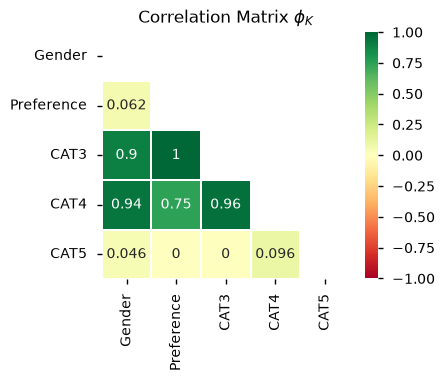

In [63]:
import phik
from phik import resources, report

# get the phi_k correlation matrix between all variables
corr_matrix = df.phik_matrix()
fig_size = int(df.shape[1]/1.2)
upper_mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=0)
plt.figure(figsize=[fig_size, fig_size])
sns.heatmap(corr_matrix, 
			mask=upper_mask,
			linewidths=0.1,
			square=True,
			cbar_kws={'shrink':0.8},
			annot=True, vmax=1, vmin=-1, cmap='RdYlGn')
plt.title(r'Correlation Matrix $\phi_K$');


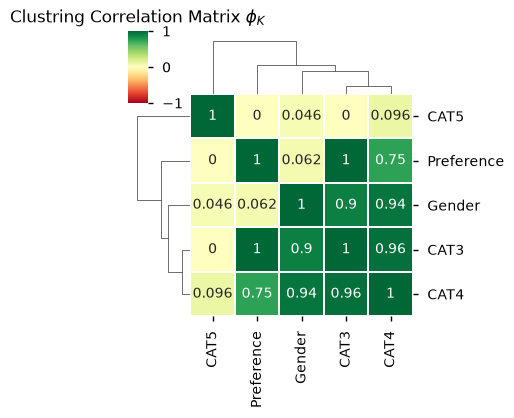

In [64]:
sns.clustermap(
    corr_matrix,
    linewidths=0.1,
    square=True,
    cbar_kws={"shrink": 0.8},
    figsize=(fig_size, fig_size),
    annot=True,
    vmax=1,
    vmin=-1,
    cmap="RdYlGn",
)
plt.title(r"Clustring Correlation Matrix $\phi_K$");

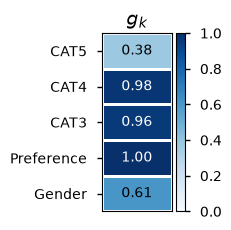

In [65]:

# get global correlations based on phi_k correlation matrix
global_correlation, global_labels = df.global_phik()
report.plot_correlation_matrix(global_correlation, x_labels=[''], y_labels=global_labels, 
                        vmin=0, vmax=1, figsize=(2.4, fig_size * 0.6),
                        color_map='Blues', title=r'$g_k$',
                        fontsize_factor=1.)
plt.tight_layout()
